# NFL Player Performance — Eksplorativna Analiza Podataka

Ovaj notebook predstavlja strukturiranu, kompletnu eksplorativnu analizu podataka za NFL igrače po pozicijama:

QB (quarterback), RB (running back), TE (tight end) i WR (wide receiver).

| Position | Data Source | Method |
|----------|-------------|--------|
| Quarterback | [Pro Football Reference](https://www.pro-football-reference.com) and [NFL Elo](https://www.nfeloapp.com/qb-rankings/) | Selenium web scraper and pre-built dataset |
| Running Back | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Tight End | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Wide Receiver | [HuggingFace / nflverse](https://huggingface.co/datasets/SebastianAndreu/24679_NFL_WR_Dataset_2025) | Pre-built dataset |

In [8]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from notebook_setup import *
from notebook_setup import setup
setup()

In [9]:
DATA_DIR = os.path.join("..", "data", "fully combined")

qb = pd.read_csv(os.path.join(DATA_DIR, "qb_master.csv"))
rb = pd.read_csv(os.path.join(DATA_DIR, "rb_master.csv"))
te = pd.read_csv(os.path.join(DATA_DIR, "te_master.csv"))
wr_seasons = pd.read_csv(os.path.join(DATA_DIR, "wr_all_seasons.csv"))

datasets = {
    "QB (qb_master)":          qb,
    "RB (rb_master)":          rb,
    "TE (te_master)":          te,
    "WR (wr_all_seasons)": wr_seasons,
}

print("Skupovi podataka uspješno učitani:\n")
for name, df in datasets.items():
    print(f"  {name:40s}    {df.shape[0]:>6} redova  ×  {df.shape[1]:>3} kolona")

Skupovi podataka uspješno učitani:

  QB (qb_master)                                 845 redova  ×  186 kolona
  RB (rb_master)                                 622 redova  ×  113 kolona
  TE (te_master)                                 194 redova  ×   60 kolona
  WR (wr_all_seasons)                           5529 redova  ×   99 kolona


- QB skup ima 845 redova i 186 kolona - najveći broj feature-a zbog kombinacije standardnih sezonskih statistika, naprednih passing metrika, ELO rejting komponenti i snap count podataka. Svaki red = jedna sezona jednog QB-a.
- RB skup ima 622 redova i 113 kolona - uključuje rushing i receiving statistike, napredne metrike poput broken tackles i YBC/YAC, te defensive i snap count kolone.
- TE skup je najmanji sa 194 reda i 60 kolona - fokusiran na receiving i rush statistike tight end-ova.
- WR Seasons je najobimniji skup sa 5.529 redova i 99 kolona - prikupljen iz nflverse/nflfastR izvora i sadrži kontekstualne varijable (situacione metrike, VP sekcije, vremenske uslove).

In [10]:
for name, df in datasets.items():
    print(f"{'_'*70}")
    print(f"  {name}")
    display(df.head(3))

______________________________________________________________________
  QB (qb_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,QBrec,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,1D,Succ%,Lng,Y/A,AY/A,Y/C,Y/G,Rate,...,elo_Penalties,elo_Points,elo_QB Elo,elo_QBR,elo_Rushing,elo_Sacks,elo_Sacks.1,elo_Starts,elo_Success,elo_T,elo_TD%,elo_TD%-INT%,elo_TDs,elo_TDs.1,elo_Total,elo_Total WPA,elo_W,elo_WPA / DB,elo_YAC,elo_YPA,elo_YPC,elo_Yards,elo_Yards.1,elo_aDOT,elo_vs Sticks
0,Josh Allen,AlleJo02,2018,22,BUF,QB,12,11,5-6-0,169,320,52.80,2074,10,3.10,12,3.80,89,37.10,75.00,6.50,5.42,12.30,172.80,67.90,...,-0.01,-0.79,136.35,49.80,0.07,28.00,0.01,11.00,0.43,0.00,0.03,-0.01,10.00,8.00,2.33,-0.18,5.00,-0.00,-0.08,6.41,7.86,2044.00,637.00,11.00,1.37
1,Josh Allen,AlleJo02,2019,23,BUF,QB,16,16,10-6-0,271,461,58.80,3089,20,4.30,9,2.00,146,41.70,53.00,6.70,6.69,11.40,193.10,85.30,...,0.00,-0.13,157.14,49.40,0.03,38.00,0.01,16.00,0.45,0.00,0.04,0.02,20.00,9.00,30.56,1.08,10.00,0.00,-0.07,6.74,5.54,3089.00,521.00,9.31,0.02
2,Josh Allen,AlleJo02,2020,24,BUF,QB,16,16,13-3-0,396,572,69.20,4544,37,6.50,10,1.70,228,56.50,55.00,7.90,8.45,11.50,284.00,107.20,...,-0.00,4.18,294.01,76.60,0.01,26.00,0.04,16.00,0.56,0.00,0.06,0.05,37.00,8.00,207.25,5.30,13.00,0.01,0.01,7.94,5.65,4544.00,441.00,8.49,-0.67


______________________________________________________________________
  RB (rb_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Succ%,Rush_Lng,Rush_Y/A,Rush_Y/G,Rush_A/G,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,...,def_FR,def_FRTD,def_FR_TD,def_FR_Yds,def_Fmb,def_PD,def_QBHits,def_Sfty,def_Sk,def_Solo,def_TFL,def_Tkl_Ast,def_Tkl_Comb,def_Tkl_Solo,def_safety_md,def_tackles_loss,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,snp_defense,snp_offense,snp_special_teams
0,Saquon Barkley,BarkSa00,2018,21,NYG,NFL,RB,16,16,261,1307,11,50,39.80,78.00,5.00,81.70,16.30,121,91,721,7.90,4,30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Saquon Barkley,BarkSa00,2019,22,NYG,NFL,RB,13,13,217,1003,6,45,43.30,68.00,4.60,77.20,16.70,73,52,438,8.40,2,14,NaN,...,2.00,0.00,NaN,NaN,1.00,0.00,0.00,NaN,0.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,728.00,1.00
2,Saquon Barkley,BarkSa00,2020,23,NYG,NFL,RB,2,2,19,34,0,1,26.30,18.00,1.80,17.00,9.50,9,6,60,10.00,0,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,67.00,0.00


______________________________________________________________________
  TE (te_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,rec_success,rec_long,Rec_R/G,Rec_Y/G,catch_pct,Y/Tgt,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,...,av,awards,adv_ADOT,adv_Drop,adv_Drop%,adv_Rec_Att/Br,adv_Rec_BrkTkl,adv_Rec_Int,adv_Rec_YAC,adv_Rec_YAC/R,adv_Rec_YBC,adv_Rec_YBC/R,adv_Rush_Att/Br,adv_Rush_BrkTkl,adv_Rush_YAC,adv_Rush_YAC/Att,adv_Rush_YBC,adv_Rush_YBC/Att,adv_rec_pass_rating,snp_Def%,snp_Off%,snp_ST%,snp_defense,snp_offense,snp_special_teams
0,Brock Bowers,BoweBr01,2024,22,LVR,NFL,TE,17,16,153,112,1194,10.70,5,61,60.80,57.00,6.60,70.20,73.20,7.80,5,13,0,2,...,9,NaN,6.10,6.00,3.90,18.70,6.00,5.00,596.00,5.30,598.00,5.30,5.00,1.00,14.00,2.80,-1.00,-0.20,92.90,NaN,NaN,NaN,NaN,NaN,NaN
1,Brock Bowers,BoweBr01,2025,23,LVR,NFL,TE,12,8,86,64,680,10.60,7,36,60.50,38.00,5.30,56.70,74.40,7.90,2,2,0,0,...,5,NaN,6.50,4.00,4.70,21.30,3.00,3.00,305.00,4.80,375.00,5.90,NaN,0.00,3.00,1.50,-1.00,-0.50,109.60,NaN,NaN,NaN,NaN,NaN,NaN
2,C.J. Uzomah,UzomC.00,2015,22,CIN,NFL,TE,5,0,1,1,4,4.00,0,1,100.00,4.00,0.20,0.80,100.00,4.00,0,0,0,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,48.00,79.00


______________________________________________________________________
  WR (wr_all_seasons)


,receiver_player_id,receiver_player_name,season,games_played,posteam,targets,receptions,receiving_yards,air_yards,yac,tds,red_zone_targets,end_zone_targets,third_down_targets,fourth_down_targets,high_leverage_targets,explosive_plays,first_downs,second_and_long_targets,third_and_medium_targets,lost_yards_due_to_penalty,yards_Q1,yards_Q2,yards_Q3,yards_Q4,...,yac_per_reception,td_rate,trailing_pct,leading_pct,wp_var,target_share_std,temp_f,humidity_pct,wind_mph,success_rate,big_play_rate,reception_std,avg_start_yardline,avg_target_depth_vs_qb,pregame_spread,pregame_total,passer_player_id,surface,is_dome,is_rain,is_snow,is_clear,defteam,home_team,away_team
0,00-0027944,J.Jones,2015,16,2,203.00,136.00,1871.00,2061.00,641.00,8.00,22,0,45,3,65,25.00,93.00,40.00,9.00,0.00,429.00,518.00,455.00,469.00,...,4.59,0.04,0.00,0.69,0.02,0.16,38.75,29.69,3.62,0.67,0.12,10.03,57.50,2.40,1.06,47.72,00-0026143,3.38,0.56,0.00,0.00,1.00,20.62,11.38,11.25
1,00-0027944,J.Jones,2016,17,2,154.00,102.00,1743.00,2096.00,511.00,9.00,15,0,27,2,82,33.00,81.00,39.00,9.00,0.00,313.00,509.00,641.00,280.00,...,4.66,0.06,0.00,0.80,0.03,0.10,33.00,25.06,2.94,0.66,0.22,8.75,55.49,4.59,2.65,50.65,00-0026143,3.35,0.59,0.06,0.00,0.94,18.00,9.35,10.65
2,00-0027944,J.Jones,2018,16,2,169.00,113.00,1677.00,2341.00,448.00,8.00,17,0,45,1,70,24.00,80.00,24.00,6.00,0.00,350.00,436.00,237.00,654.00,...,3.87,0.06,0.00,0.79,0.03,0.14,40.69,40.75,3.50,0.66,0.14,8.71,54.18,5.14,2.81,50.47,00-0026143,3.06,0.06,0.00,0.00,1.00,16.56,11.19,7.38


### Opis pojedinih kolona po skupu podataka

---

#### QB 

| Kolona | Opis |
|--------|------|
| `Player` / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Cmp` / `Att` / `Cmp%` | Kompletirana dodavanja / pokušaji / procenat |
| `Yds` / `TD` / `Int` | Passing jardi / touchdowni / intercepcije |
| `Y/A` | Jardi po pokušaju |
| `Rate` | NFL Passer Rating |
| `QBR` | ESPN Total QBR (0-100, napredna metrika) |
| `adv_pass_*` | Napredne passing metrike (air yards, pressure, play-action itd.) |
| `elo_*` | ELO rejting komponente (CPOE, WPA, rushing itd.) |
| `snp_Off%` | Procenat offensive snapova |

---

#### RB 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `Rush_Att` / `Rush_Yds` / `Rush_TD` | Rushing pokušaji / jardi / touchdowni |
| `Rush_Y/A` | Jardi po pokušaju (yards per carry) |
| `Rec` / `Rec_Yds` / `Rec_TD` | Receiving statistike |
| `Scrimmage_Yds` / `Touches` | Ukupni jardi i dodiri lopte (rush + rec) |
| `adv_Rush_BrkTkl` | Broken tackles |
| `adv_Rush_YBC` / `adv_Rush_YAC` | Yards before/after contact |


---

#### TE 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Tgt` / `Rec` / `Rec_Yds` / `Rec_TD` | Targeti / hvatanja / jardi / touchdowni |
| `Rec_Y/R` | Jardi po hvatanju |
| `catch_pct` | Procenat uhvacenih targeta |
| `adv_ADOT` | Average Depth of Target (prosjecna dubina targeta) |
| `adv_Rec_YAC` / `adv_Rec_YBC` | Yards after catch / yards before contact |

---

#### WR Seasons

| Kolona | Opis |
|--------|------|
| `receiver_player_name` / `season` | Identifikacija igrača i sezone |
| `targets` / `receptions` / `receiving_yards` / `tds` | Osnovne receiving statistike |
| `catch_rate` / `target_share` | Efikasnost i udio u timskim targetima |
| `adot` | Average Depth of Target (prosjecna dubina targeta) |
| `air_yards` / `yac` | Air jardi i yards after catch |
| `epa` / `wpa` | Expected Points Added / Win Probability Added |
| `red_zone_targets` | Targeti u red zone |
| `temp_f` / `wind_mph` / `surface` | Vremenski uslovi i tip terena |
| `yards_Q1/Q2/Q3/Q4` / `receptions_Q1/.../Q4` | Situacioni splitovi po kvartalu i win probability bucketima |
| `pregame_spread` / `pregame_total` | Kontekstualni podaci - spread, total |

In [11]:
rows = []
for name, df in datasets.items():
    for dtype, count in df.dtypes.value_counts().items():
        rows.append({"Pozicija": name.split("(")[0].strip(), "Tip": str(dtype), "Broj kolona": count})

result = pd.DataFrame(rows).pivot_table(index="Pozicija", columns="Tip", values="Broj kolona", fill_value=0).astype(int)
result.index.name = None
result.columns.name = None
display(result)

,float64,int64,object
QB,162,15,9
RB,90,14,9
TE,37,18,5
WR,80,16,3


- Većina kolona su tipa `float64` - numeričke statistike sa mogućim `NaN` vrednostima.
- Kategorijske kolone poput `Player`, `Team`, `PlayerID`, `surface`, `awards` itd. su tipa `object` (string).

---
## Analiza Nedostajućih Vrijednosti

Pregled ukupnog broja i procenta `NaN` vrijednosti po skupu podataka, kao i vizualizacija kolona s najviše nedostajućih vrijednosti.

In [12]:
# Sažetna tabela nedostajućih vrijednosti po skupu
null_summary = []
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    cols_with_nulls = (df.isnull().sum() > 0).sum()
    null_summary.append({
        "Skup": name.split("(")[0].strip(),
        "Ukupno ćelija": total_cells,
        "Null ćelija": total_nulls,
        "Null %": round(total_nulls / total_cells * 100, 2),
        "Kolona s nullovima": cols_with_nulls,
        "Ukupno kolona": df.shape[1],
    })

display(pd.DataFrame(null_summary))

,Skup,Ukupno ćelija,Null ćelija,Null %,Kolona s nullovima,Ukupno kolona
0,QB,157170,57521,36.60,167,186
1,RB,70286,33089,47.08,92,113
2,TE,11640,2154,18.51,37,60
3,WR,547371,0,0.00,0,99


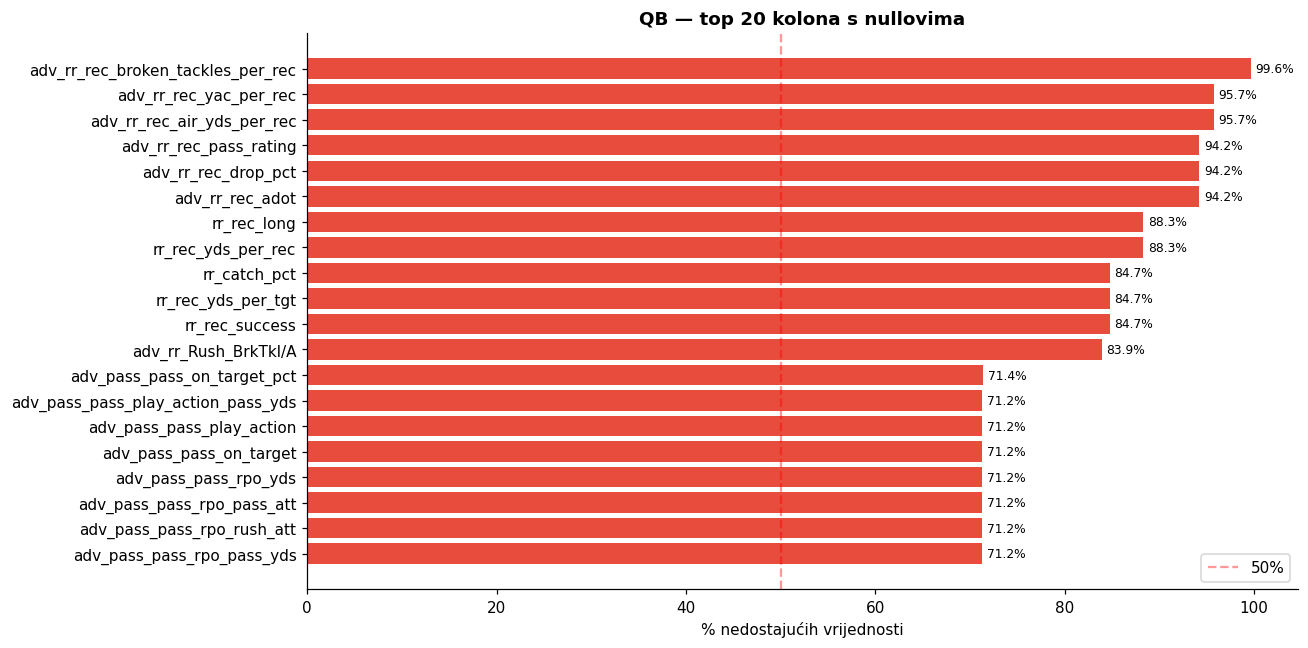

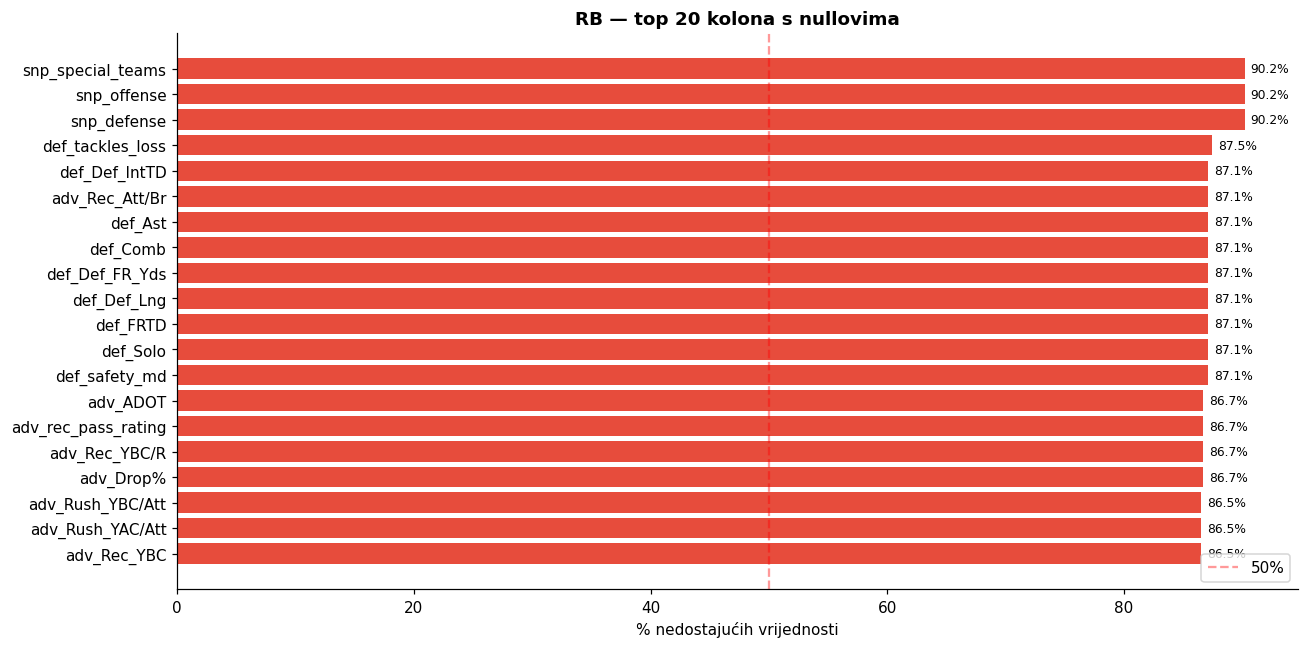

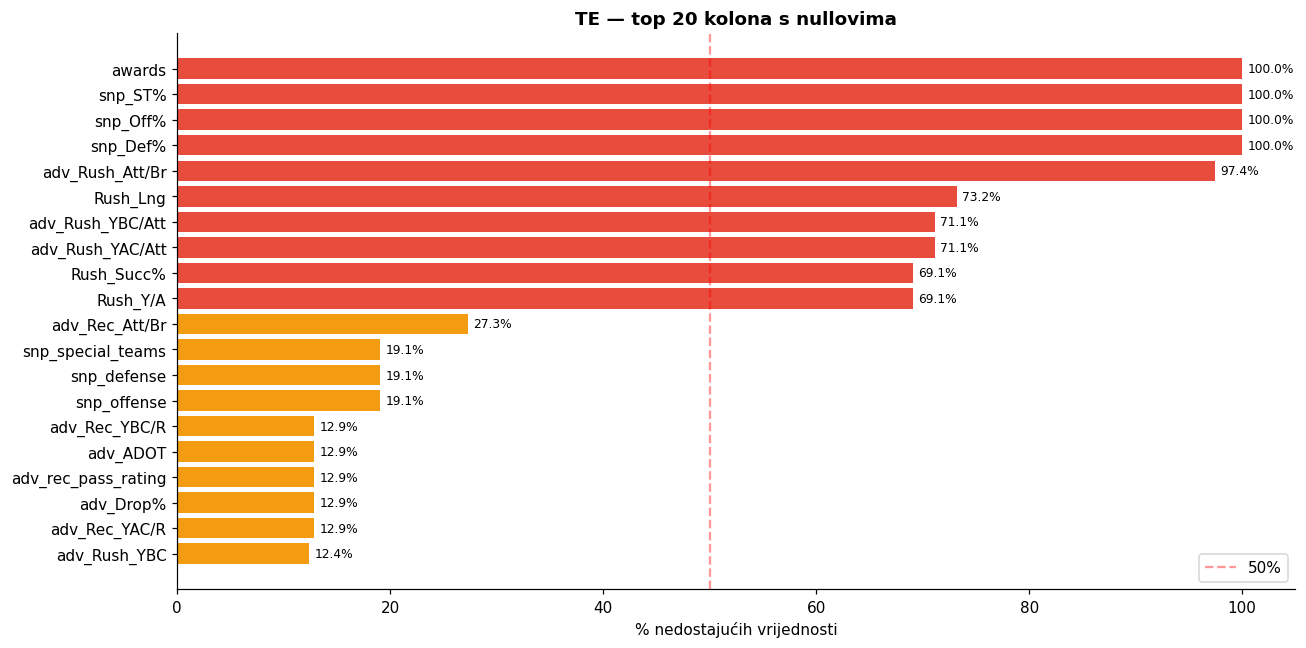

WR: nema nedostajućih vrijednosti.


In [13]:
# Vizualizacija top 20 kolona s najviše nullova po skupu
def plot_missing(df, name, top_n=20):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=False).head(top_n)
    if null_pct.empty:
        print(f"{name}: nema nedostajućih vrijednosti.")
        return
    fig, ax = plt.subplots(figsize=(12, max(3, len(null_pct) * 0.3)))
    colors = ["#e74c3c" if v >= 50 else "#f39c12" if v >= 10 else "#2ecc71" for v in null_pct.values]
    ax.barh(null_pct.index[::-1], null_pct.values[::-1], color=colors[::-1])
    ax.axvline(50, color="red", linestyle="--", alpha=0.4, label="50%")
    ax.set_xlabel("% nedostajućih vrijednosti")
    ax.set_title(f"{name} — top {len(null_pct)} kolona s nullovima", fontweight="bold")
    ax.legend()
    for i, v in enumerate(null_pct.values[::-1]):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_missing(df, name.split("(")[0].strip())

Visok procenat null vrednosti u ovim kolonama nije greška u podacima - to je posledica prirode same pozicije. Statistike koje za neku poziciju gotovo i ne postoje jednostavno neće biti popunjene.


 Na primer, QB skupu kolone poput `adv_rr_rec_drop_pct` ili `adv_rr_rec_yac_per_rec` odnose se na receiving metrike — QB praktično nikad nije targetiran kao receiver, pa su te vrijednosti null.


Ove kolone su u skupu podataka prisutne jer se koristi isti šablon kolekcije podataka za sve igrače, ali pri modeliranju će biti isključene ili ignorisane kao nebitne za predviđanje performansi te pozicije.

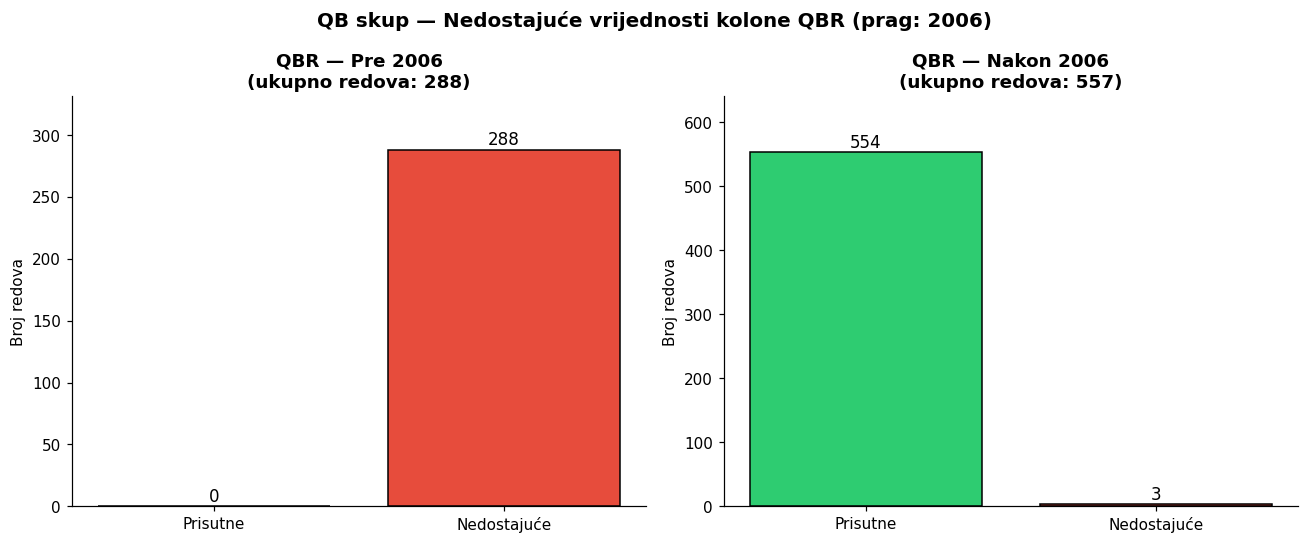

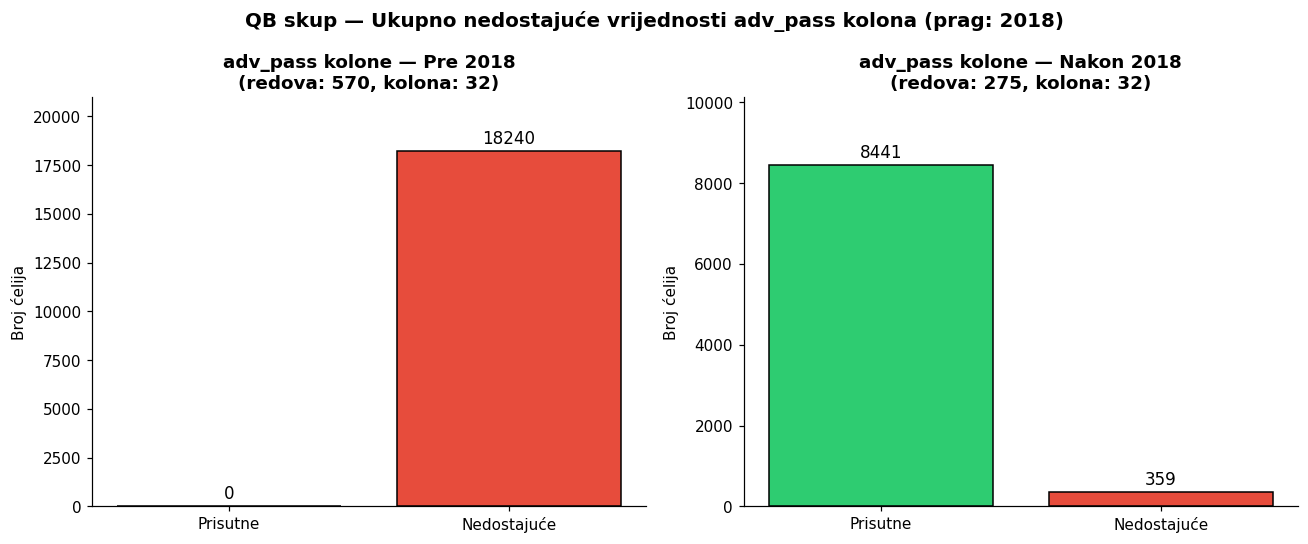

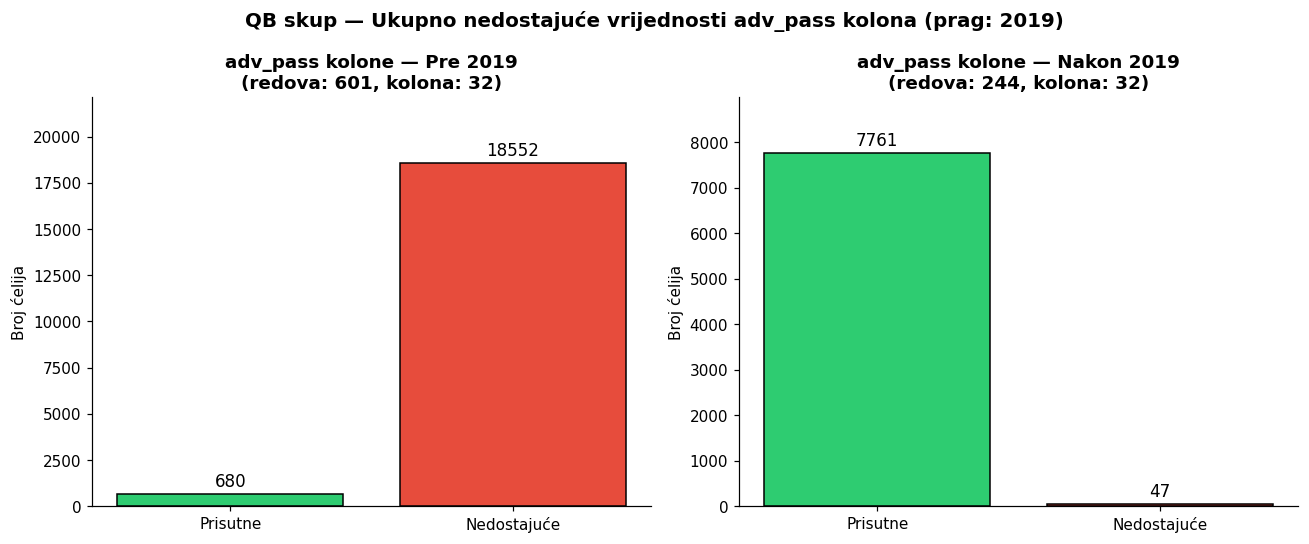

In [14]:

adv_pass_cols = [c for c in qb.columns if c.startswith("adv_pass")]

# --- QBR: broj nedostajućih vrijednosti prije i nakon 2006 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, mask) in zip(axes, [("Pre 2006", qb["Season"] < 2006), ("Nakon 2006", qb["Season"] >= 2006)]):
    subset = qb[mask]
    missing = subset["QBR"].isnull().sum()
    present = subset["QBR"].notnull().sum()
    ax.bar(["Prisutne", "Nedostajuće"], [present, missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(f"QBR — {label}\n(ukupno redova: {len(subset)})", fontweight="bold")
    ax.set_ylabel("Broj redova")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
    ax.set_ylim(0, len(subset) * 1.15)

fig.suptitle("QB skup — Nedostajuće vrijednosti kolone QBR (prag: 2006)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- adv_pass kolone: ukupan broj nedostajućih vrijednosti za različite pragove ---
def plot_adv_pass_missing(year):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (label, mask) in zip(axes, [(f"Pre {year}", qb["Season"] < year), (f"Nakon {year}", qb["Season"] >= year)]):
        subset = qb[mask]
        total_cells = len(subset) * len(adv_pass_cols)
        total_missing = subset[adv_pass_cols].isnull().sum().sum()
        total_present = total_cells - total_missing
        ax.bar(["Prisutne", "Nedostajuće"], [total_present, total_missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
        ax.set_title(f"adv_pass kolone — {label}\n(redova: {len(subset)}, kolona: {len(adv_pass_cols)})", fontweight="bold")
        ax.set_ylabel("Broj ćelija")
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_cells * 0.01,
                    str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
        ax.set_ylim(0, total_cells * 1.15)
    fig.suptitle(f"QB skup — Ukupno nedostajuće vrijednosti adv_pass kolona (prag: {year})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

for year in [2018, 2019]:
    plot_adv_pass_missing(year)




QBR (prag: 2006)

ESPN Total QBR metrika uvedena je 2006. godine, što objašnjava zašto svih 288 QB sezona pre 2006. nema QBR vrednost (100% null). Nakon 2006. samo 3 od 557 redova nemaju QBR. Ovo je strukturalni nedostatak podataka uslovljen datumom uvođenja metrike, a ne greškom u prikupljanju.

---
adv_pass kolone (prag: 2018)

Pro Football Reference je 2018. godine uveo prvi set naprednih passing statistika (`adv_pass` kolone). Pre te godine nijedna od ovih kolona nije postojala, pa je prisutnost podataka za sezone pre 2018. ravna 0% - svi redovi su null. Nakon 2018. većina `adv_pass` kolona je popunjena, što potvrđuje da se radi o strukturalnom nedostatku vezanom za datum uvođenja metrika, a ne o greškama u prikupljanju.

---
adv_pass kolone (prag: 2019)

Iako su napredne passing statistike uvedene 2018., skup kolona je proširen 2019. godine dodatnim metrikama. Kolone poput play action yards, play action attempts, run-pass option (RPO) attempts i yards, on-target throws, on-target throw % i druge nisu postojale u sezoni 2018. i počele su se bežiti tek od 2019. To objašnjava zašto grafik s pragom 2019. pokazuje još manji broj nedostajućih vrednosti  - jer su sve `adv_pass` kolone (uključujući i one dodane 2019.) tada potpuno dostupne, dok u sezoni 2018. te novije kolone još uvijek imaju null vrednosti.


---
## Analiza Outliera (Odstupajućih Vrijednosti)

Outlieri su opservacije koje značajno odstupaju od ostatka distribucije. U NFL podacima, outlieri mogu biti:

- **Legitimni** — elitni igrači s izvanrednim performansama (npr. Patrick Mahomes, Derrick Henry)
- **Artefakti malog uzorka** — igrači s vrlo malo odigranih utakmica koji imaju ekstremne per-game statistike

Koristimo dvije metode detekcije:

1. **IQR metoda** (Interquartile Range) — outlier je svaka vrijednost izvan raspona $[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]$
2. **Z-score metoda** — outlier je svaka vrijednost gdje je $|z| > 3$ (više od 3 standardne devijacije od prosjeka)

### Ključne kolone za analizu outliera po poziciji

Odabiramo najreprezentativnije performance metrike za svaku poziciju — kolone koje direktno mjere produktivnost igrača i najčešće se koriste u fantasy/analitičkom kontekstu.

In [15]:
# Definicija ključnih kolona za outlier analizu po poziciji
key_cols = {
    "QB": {
        "df": qb,
        "cols": ["Yds", "TD", "Int", "Cmp%", "Y/A", "Rate", "QBR"],
        "id_col": "Player",
    },
    "RB": {
        "df": rb,
        "cols": ["Rush_Att", "Rush_Yds", "Rush_TD", "Rush_Y/A", "Rec", "Rec_Yds", "Scrimmage_Yds"],
        "id_col": "Player",
    },
    "TE": {
        "df": te,
        "cols": ["Tgt", "Rec", "Rec_Yds", "Rec_TD", "Rec_Y/R"],
        "id_col": "Player",
    },
    "WR": {
        "df": wr_seasons,
        "cols": ["targets", "receptions", "receiving_yards", "tds", "catch_rate", "target_share", "adot"],
        "id_col": "receiver_player_name",
    },
}

# Provjera da sve kolone postoje
for pos, info in key_cols.items():
    missing = [c for c in info["cols"] if c not in info["df"].columns]
    if missing:
        print(f"⚠ {pos}: nedostaju kolone {missing}")
    else:
        print(f"✔ {pos}: sve kolone pronađene ({len(info['cols'])})")


✔ QB: sve kolone pronađene (7)
✔ RB: sve kolone pronađene (7)
✔ TE: sve kolone pronađene (5)
✔ WR: sve kolone pronađene (7)


### IQR Analiza — Sažetak Outliera po Poziciji

Za svaku ključnu kolonu računamo:
- Q1, Q3, IQR
- Donju i gornju granicu ($Q_1 - 1.5 \cdot IQR$ i $Q_3 + 1.5 \cdot IQR$)
- Broj i procenat outliera

In [16]:
def iqr_outlier_summary(df, cols, pos_name):
    """Računa IQR-bazirane outliere za odabrane kolone."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({
            "Pozicija": pos_name,
            "Kolona": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "Donja granica": round(lower, 2),
            "Gornja granica": round(upper, 2),
            "N (valid)": len(s),
            "Outliera": n_out,
            "Outlier %": round(n_out / len(s) * 100, 1),
        })
    return pd.DataFrame(rows)

# Kreiramo sažetak za sve pozicije
iqr_all = pd.concat(
    [iqr_outlier_summary(info["df"], info["cols"], pos) for pos, info in key_cols.items()],
    ignore_index=True
)

display(iqr_all.style.background_gradient(subset=["Outlier %"], cmap="OrRd")
        .format({"Outlier %": "{:.1f}%"})
        .set_caption("IQR Outlier Sažetak — sve pozicije"))


,Pozicija,Kolona,Q1,Q3,IQR,Donja granica,Gornja granica,N (valid),Outliera,Outlier %
0,QB,Yds,1799.000000,3983.000000,2184.000000,-1477.000000,7259.000000,845,0,0.0%
1,QB,TD,9.000000,26.000000,17.000000,-16.500000,51.500000,845,1,0.1%
2,QB,Int,6.000000,14.000000,8.000000,-6.000000,26.000000,845,6,0.7%
3,QB,Cmp%,59.000000,66.000000,7.000000,48.500000,76.500000,836,28,3.3%
4,QB,Y/A,6.600000,7.700000,1.100000,4.950000,9.350000,836,34,4.1%
5,QB,Rate,79.350000,96.700000,17.350000,53.330000,122.720000,836,30,3.6%
6,QB,QBR,47.100000,66.780000,19.680000,17.590000,96.290000,554,22,4.0%
7,RB,Rush_Att,135.250000,278.000000,142.750000,-78.880000,492.120000,622,0,0.0%
8,RB,Rush_Yds,554.500000,1213.250000,658.750000,-433.620000,2201.380000,622,0,0.0%
9,RB,Rush_TD,3.000000,9.750000,6.750000,-7.120000,19.880000,622,7,1.1%


### Box Plotovi — Vizualizacija Distribucija i Outliera

Box plotovi prikazuju distribuciju ključnih metrika za svaku poziciju. Tačke izvan "brkova" (whiskers) predstavljaju IQR outliere.

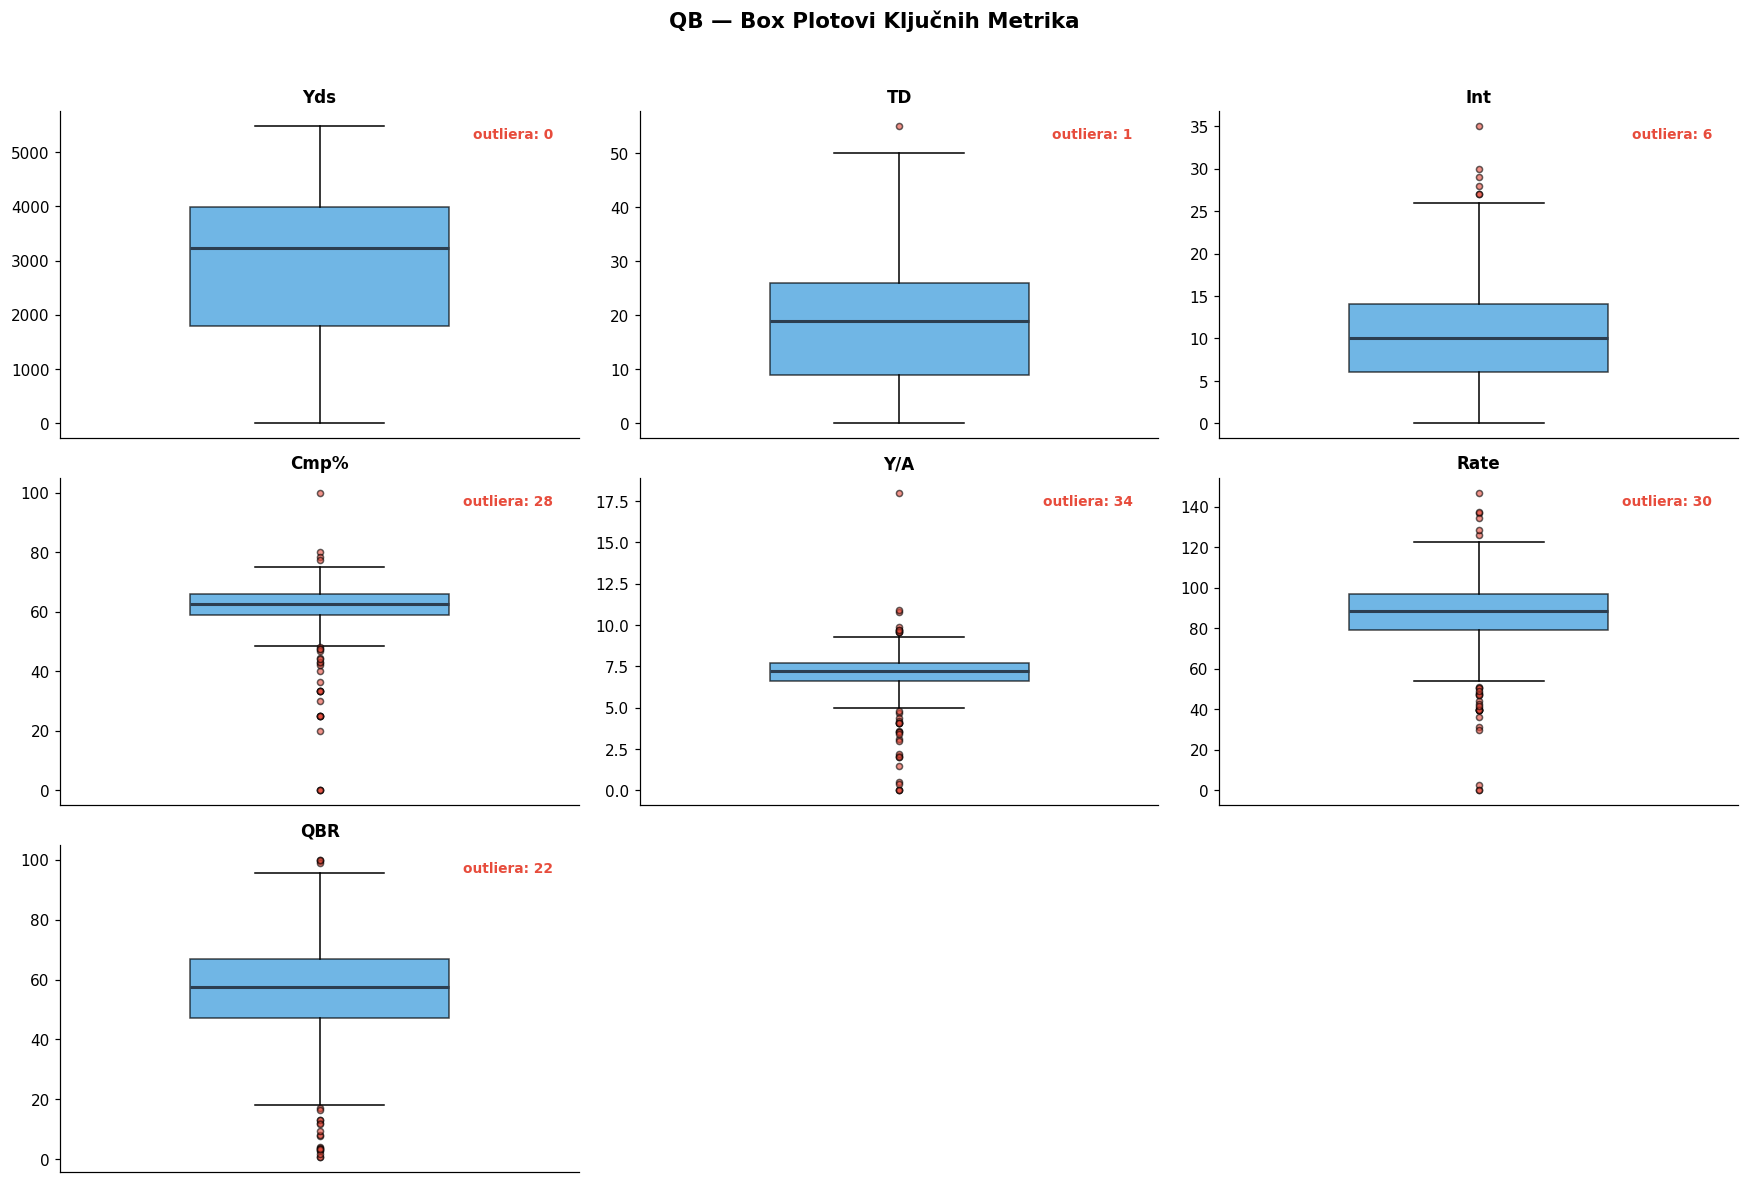

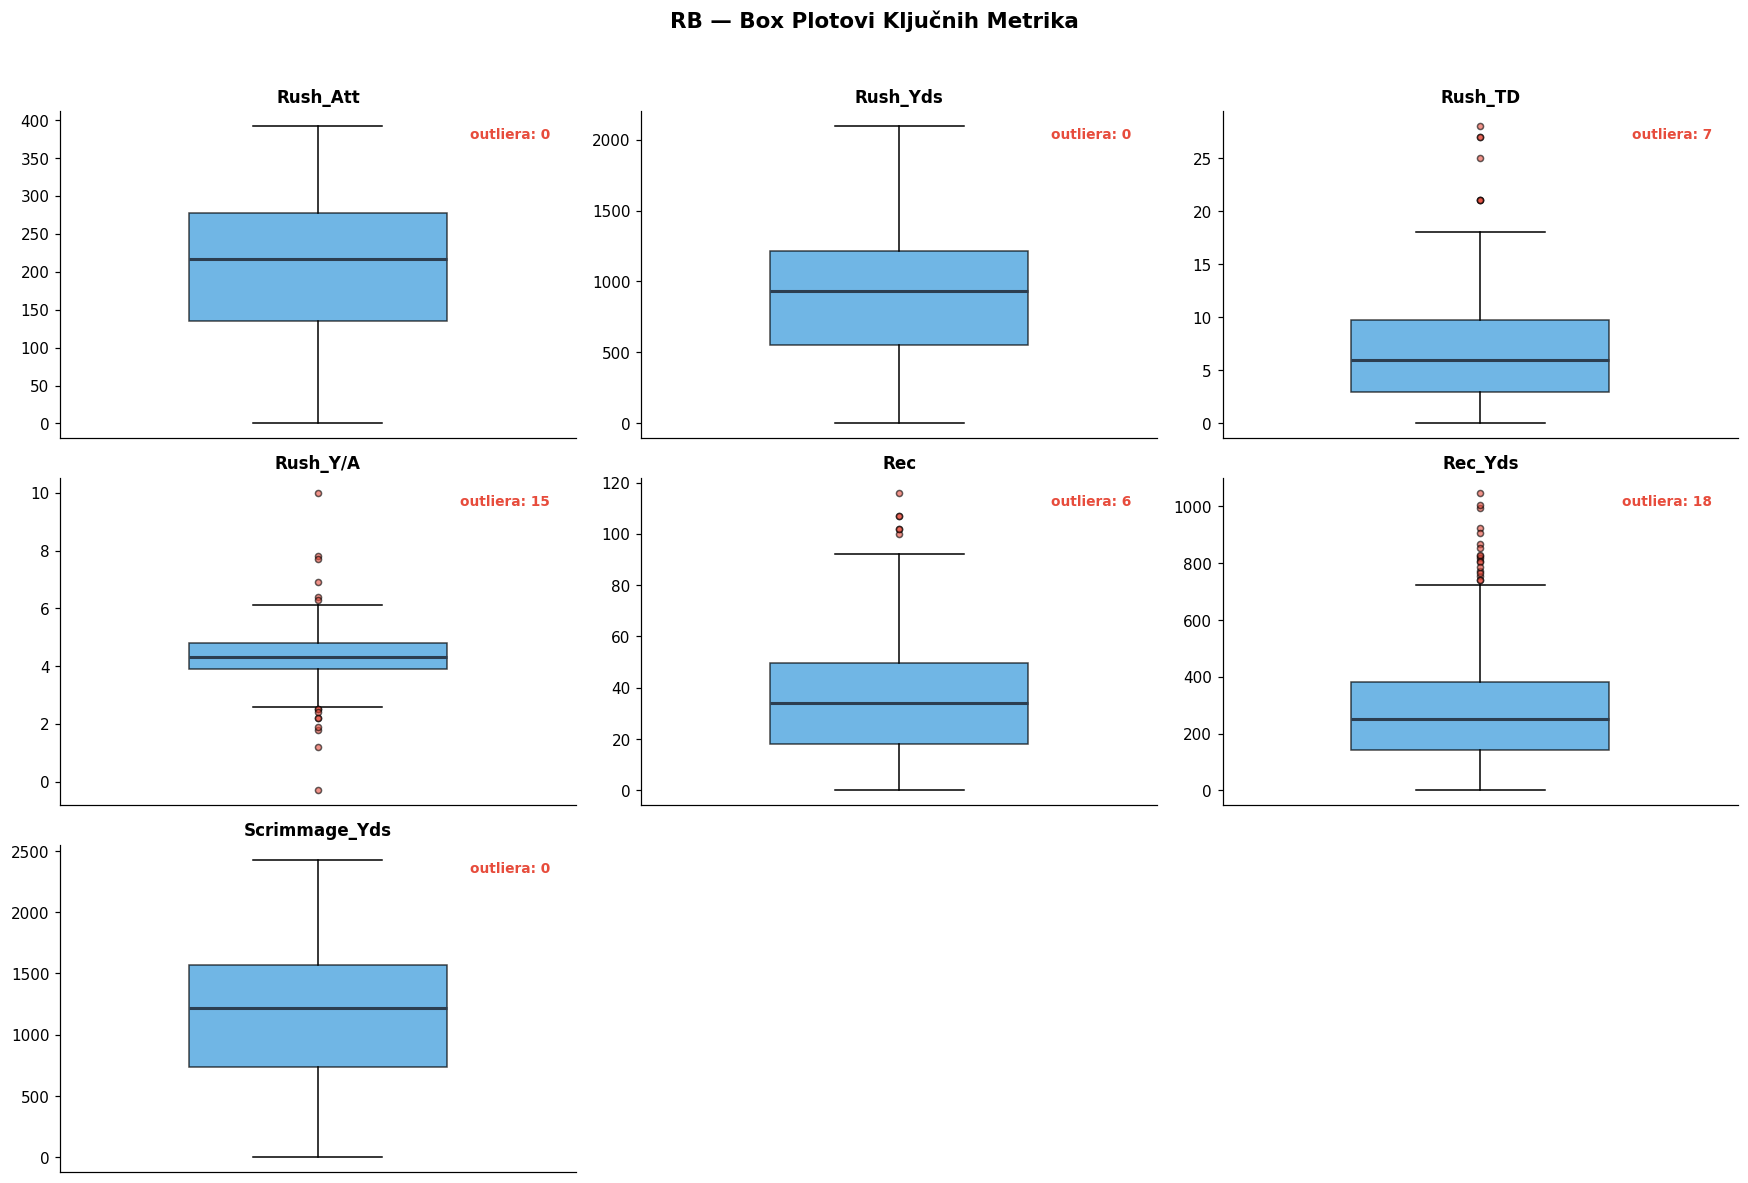

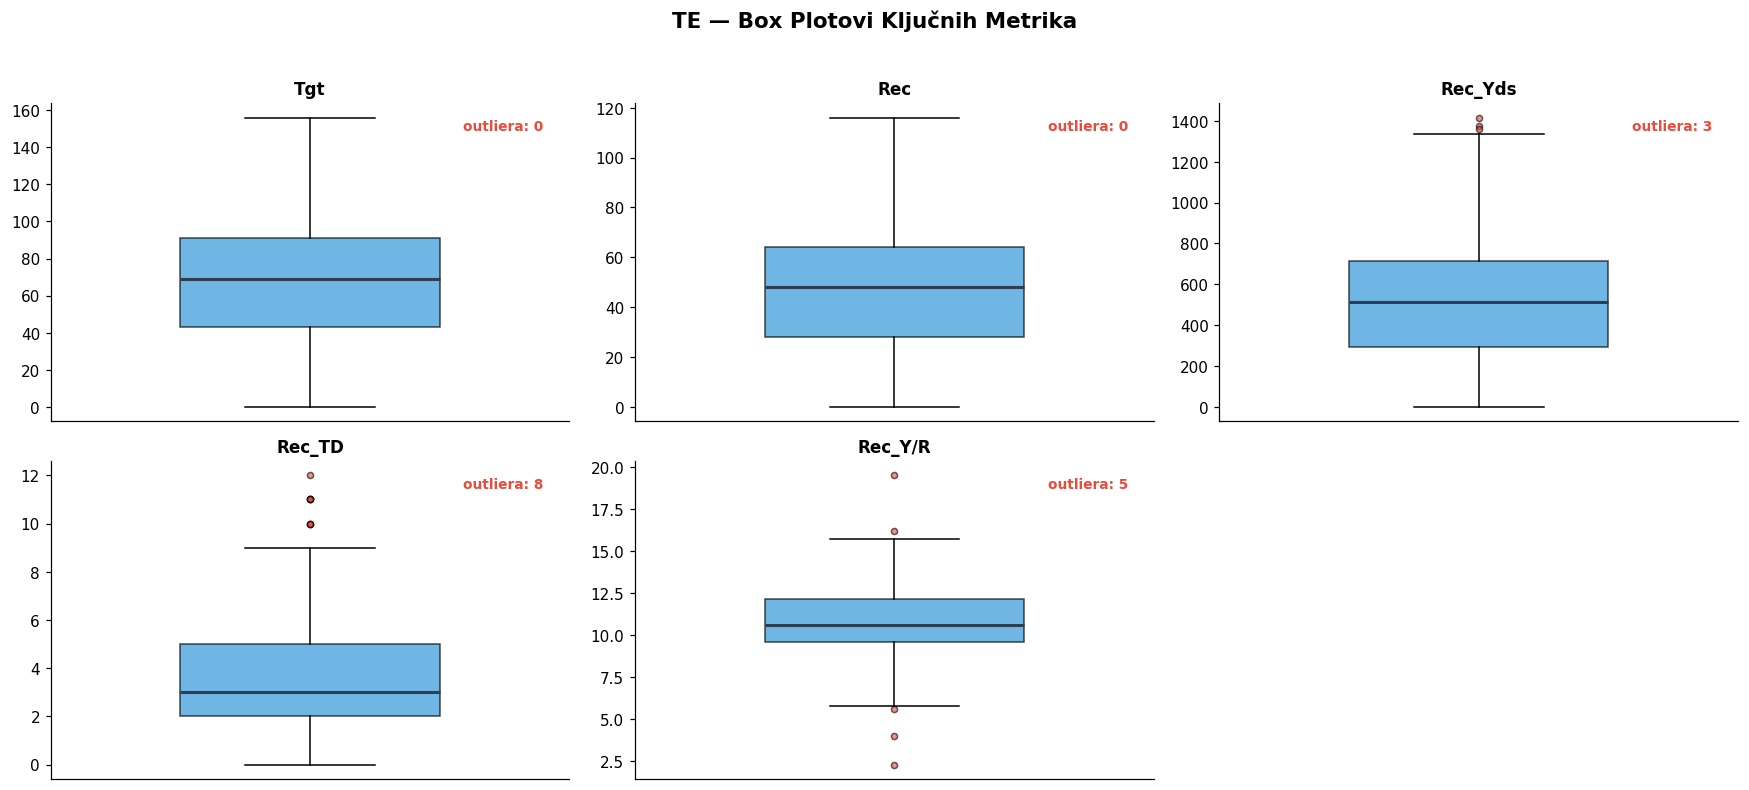

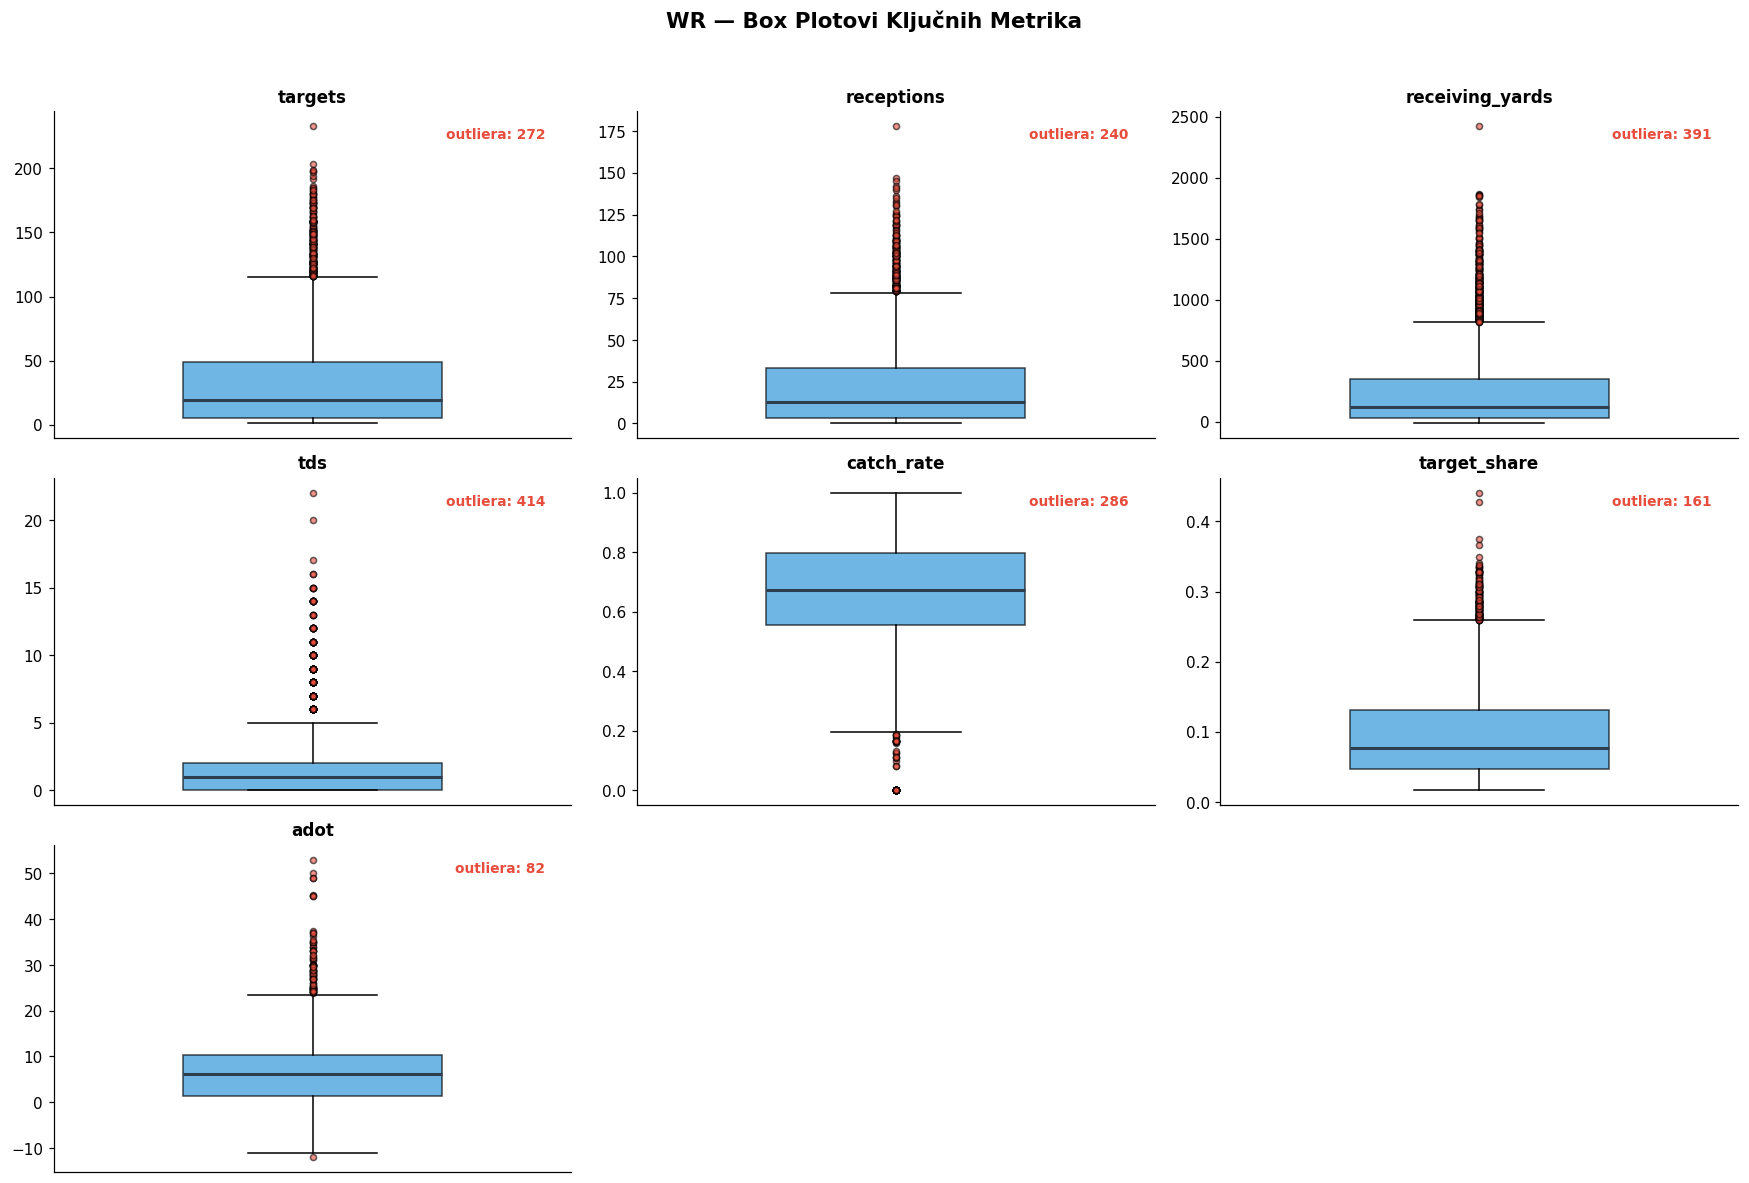

In [17]:
for pos, info in key_cols.items():
    df_pos = info["df"]
    cols = info["cols"]
    n_cols = len(cols)
    n_rows = (n_cols + 2) // 3

    fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df_pos[col].dropna()
        bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5,
                        boxprops=dict(facecolor="#3498db", alpha=0.7),
                        flierprops=dict(marker="o", markerfacecolor="#e74c3c", markersize=4, alpha=0.6),
                        medianprops=dict(color="#2c3e50", linewidth=2))
        ax.set_title(col, fontweight="bold", fontsize=11)
        ax.set_xticks([])

        # Anoticija broja outliera
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data < lower) | (data > upper)).sum()
        ax.text(0.95, 0.95, f"outliera: {n_out}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="#e74c3c", fontweight="bold")

    # Sakri prazne subplotove
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{pos} — Box Plotovi Ključnih Metrika", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


### Z-Score Analiza — Ekstremne Vrijednosti ($|z| > 3$)

Z-score mjeri koliko standardnih devijacija je neka vrijednost udaljena od prosjeka: $z = \frac{x - \mu}{\sigma}$

Vrijednosti s $|z| > 3$ smatramo ekstremnim outlierima — statistički se očekuje manje od 0.3% takvih opservacija u normalnoj distribuciji.

In [18]:
from scipy import stats

z_threshold = 3

# Z-score sažetak po poziciji i koloni
z_rows = []
for pos, info in key_cols.items():
    df_pos = info["df"]
    for col in info["cols"]:
        s = df_pos[col].dropna()
        if s.empty or s.std() == 0:
            continue
        z = np.abs(stats.zscore(s))
        n_extreme = (z > z_threshold).sum()
        z_rows.append({
            "Pozicija": pos,
            "Kolona": col,
            "N (valid)": len(s),
            "z > 3": n_extreme,
            "z > 3 (%)": round(n_extreme / len(s) * 100, 2),
            "Max |z|": round(z.max(), 2),
        })

z_summary = pd.DataFrame(z_rows)
display(z_summary.style
        .background_gradient(subset=["z > 3 (%)"], cmap="OrRd")
        .background_gradient(subset=["Max |z|"], cmap="YlOrRd")
        .format({"z > 3 (%)": "{:.2f}%"})
        .set_caption("Z-Score Outlier Sažetak (|z| > 3)"))


,Pozicija,Kolona,N (valid),z > 3,z > 3 (%),Max |z|
0,QB,Yds,845,0,0.00%,1.960000
1,QB,TD,845,1,0.12%,3.280000
2,QB,Int,845,4,0.47%,4.250000
3,QB,Cmp%,836,15,1.79%,8.140000
4,QB,Y/A,836,16,1.91%,8.970000
5,QB,Rate,836,9,1.08%,5.470000
6,QB,QBR,554,9,1.62%,3.320000
7,RB,Rush_Att,622,0,0.00%,2.130000
8,RB,Rush_Yds,622,0,0.00%,2.650000
9,RB,Rush_TD,622,4,0.64%,4.390000


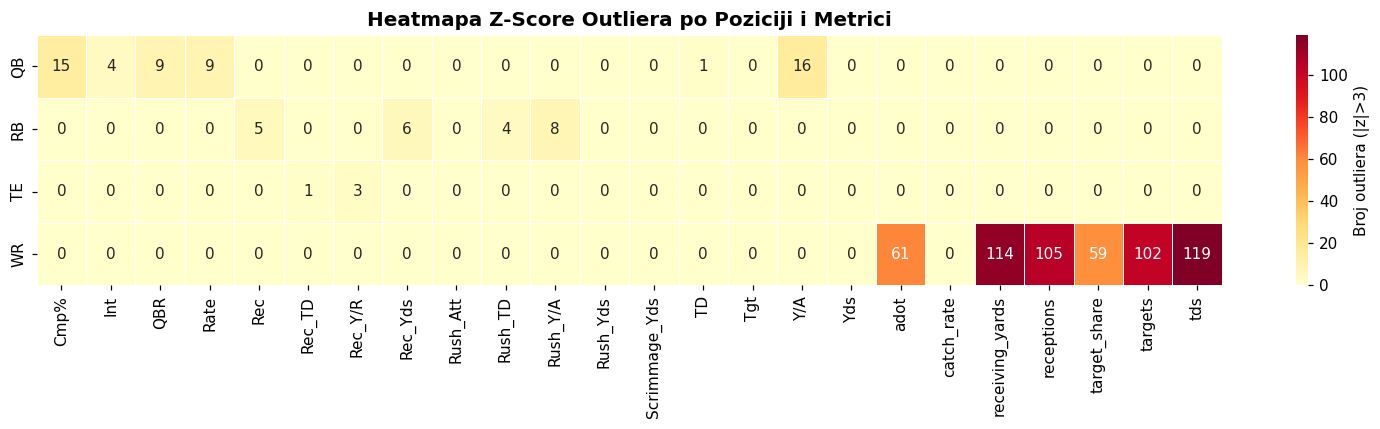

In [19]:
# Vizualizacija: Heatmapa broja z>3 outliera po poziciji i koloni
pivot = z_summary.pivot_table(index="Pozicija", columns="Kolona", values="z > 3", fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=ax, cbar_kws={"label": "Broj outliera (|z|>3)"})
ax.set_title("Heatmapa Z-Score Outliera po Poziciji i Metrici", fontweight="bold", fontsize=13)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


### Identifikacija Top Outlier Igrača

Za svaku poziciju prikazujemo igrače koji se najčešće pojavljuju kao outlieri (pojavljuju se kao outlier u više kolona istovremeno). Ovo nam pomaže razlikovati **legitimne elitne performanse** od **artefakata malog uzorka**.

In [20]:
def find_top_outliers(df, cols, id_col, pos_name, method="iqr", top_n=10):
    """
    Pronađi igrače koji su outlieri u najviše kolona.
    method: 'iqr' ili 'zscore'
    """
    outlier_flags = pd.DataFrame(index=df.index)

    for col in cols:
        s = df[col]
        if method == "iqr":
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            outlier_flags[col] = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).astype(int)
        elif method == "zscore":
            z = np.abs((s - s.mean()) / s.std())
            outlier_flags[col] = (z > 3).astype(int)

    outlier_flags["total_outlier_cols"] = outlier_flags.sum(axis=1)
    outlier_flags[id_col] = df[id_col].values

    # Dodaj Season kolonu ako postoji
    season_col = "Season" if "Season" in df.columns else "season"
    if season_col in df.columns:
        outlier_flags[season_col] = df[season_col].values

    # Dodaj G (games) ako postoji
    games_col = "G" if "G" in df.columns else None
    if games_col and games_col in df.columns:
        outlier_flags["G"] = df[games_col].values

    result = outlier_flags[outlier_flags["total_outlier_cols"] > 0].sort_values("total_outlier_cols", ascending=False).head(top_n)

    display_cols = [id_col]
    if season_col in result.columns:
        display_cols.append(season_col)
    if "G" in result.columns:
        display_cols.append("G")
    display_cols += cols + ["total_outlier_cols"]

    return result[[c for c in display_cols if c in result.columns]]


for pos, info in key_cols.items():
    print(f"\n{'='*70}")
    print(f"  {pos} — Top 10 Outlier Igrača (IQR metoda)")
    print(f"{'='*70}")
    top = find_top_outliers(info["df"], info["cols"], info["id_col"], pos, method="iqr", top_n=10)
    # Rename outlier flag cols za prikaz: 1=outlier, 0=ne
    display_df = top.copy()
    for col in info["cols"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].map({1: "⚠", 0: ""})
    display_df = display_df.rename(columns={"total_outlier_cols": "Br. outlier kolona"})
    display(display_df)



  QB — Top 10 Outlier Igrača (IQR metoda)


,Player,Season,G,Yds,TD,Int,Cmp%,Y/A,Rate,QBR,Br. outlier kolona
9,Aaron Rodgers,2006,2,,,,⚠,⚠,⚠,⚠,4
26,Aaron Rodgers,2023,1,,,,⚠,⚠,⚠,⚠,4
296,Geno Smith,2018,5,,,,⚠,⚠,⚠,⚠,4
380,Jimmy Garoppolo,2015,5,,,,⚠,⚠,⚠,⚠,4
311,Jacoby Brissett,2023,3,,,,⚠,⚠,⚠,,3
628,Randall Cunningham,1991,1,,,,⚠,⚠,⚠,,3
638,Rich Gannon,1987,4,,,,⚠,⚠,⚠,,3
105,Brett Favre,1991,2,,,,⚠,⚠,⚠,,3
720,Tom Brady,2000,1,,,,⚠,⚠,⚠,,3
756,Trent Green,1997,1,,,,⚠,⚠,⚠,,3



  RB — Top 10 Outlier Igrača (IQR metoda)


,Player,Season,G,Rush_Att,Rush_Yds,Rush_TD,Rush_Y/A,Rec,Rec_Yds,Scrimmage_Yds,Br. outlier kolona
96,Christian McCaffrey,2025,17,,,,,⚠,⚠,,2
425,Matt Forte,2014,16,,,,,⚠,⚠,,2
89,Christian McCaffrey,2018,16,,,,,⚠,⚠,,2
90,Christian McCaffrey,2019,16,,,,,⚠,⚠,,2
2,Saquon Barkley,2020,2,,,,⚠,,,,1
402,Marshall Faulk,2001,14,,,,,,⚠,,1
437,Maurice Jones-Drew,2014,12,,,,⚠,,,,1
449,Michael Turner,2006,13,,,,⚠,,,,1
481,Priest Holmes,2002,14,,,⚠,,,,,1
482,Priest Holmes,2003,16,,,⚠,,,,,1



  TE — Top 10 Outlier Igrača (IQR metoda)


,Player,Season,G,Tgt,Rec,Rec_Yds,Rec_TD,Rec_Y/R,Br. outlier kolona
154,Travis Kelce,2020,15,,,⚠,⚠,,2
2,C.J. Uzomah,2015,5,,,,,⚠,1
33,Dallas Goedert,2025,15,,,,⚠,,1
73,George Kittle,2018,16,,,⚠,,,1
77,George Kittle,2022,15,,,,⚠,,1
83,Greg Dulcich,2024,9,,,,,⚠,1
108,Ian Thomas,2024,5,,,,,⚠,1
124,Mark Andrews,2018,16,,,,,⚠,1
125,Mark Andrews,2019,15,,,,⚠,,1
127,Mark Andrews,2021,17,,,⚠,,,1



  WR — Top 10 Outlier Igrača (IQR metoda)


,receiver_player_name,season,targets,receptions,receiving_yards,tds,catch_rate,target_share,adot,Br. outlier kolona
0,J.Jones,2015,⚠,⚠,⚠,⚠,,⚠,,5
4430,C.Lamb,2022,⚠,⚠,⚠,⚠,,⚠,,5
379,A.Brown,2015,⚠,⚠,⚠,⚠,,⚠,,5
1119,T.Kelce,2020,⚠,⚠,⚠,⚠,,⚠,,5
2968,J.Smith-Schuster,2018,⚠,⚠,⚠,⚠,,⚠,,5
2970,J.Smith-Schuster,2020,⚠,⚠,⚠,⚠,,⚠,,5
1122,T.Kelce,2023,⚠,⚠,⚠,⚠,,⚠,,5
1170,D.Hopkins,2015,⚠,⚠,⚠,⚠,,⚠,,5
1172,D.Hopkins,2017,⚠,⚠,⚠,⚠,,⚠,,5
1173,D.Hopkins,2018,⚠,⚠,⚠,⚠,,⚠,,5


### Outlieri i Broj Odigranih Utakmica — Mali Uzorak vs. Elitne Performanse

Ključno pitanje: da li su outlieri posljedica izvanrednih performansi ili malog broja odigranih utakmica? Igrači koji su igrali samo 1-3 utakmice mogu imati ekstremne per-game metrike koje ne odražavaju stvarni nivo igre.

Vizualiziramo odnos broja utakmica (`G`) i ključne metrike za QB i RB, te označavamo outliere.

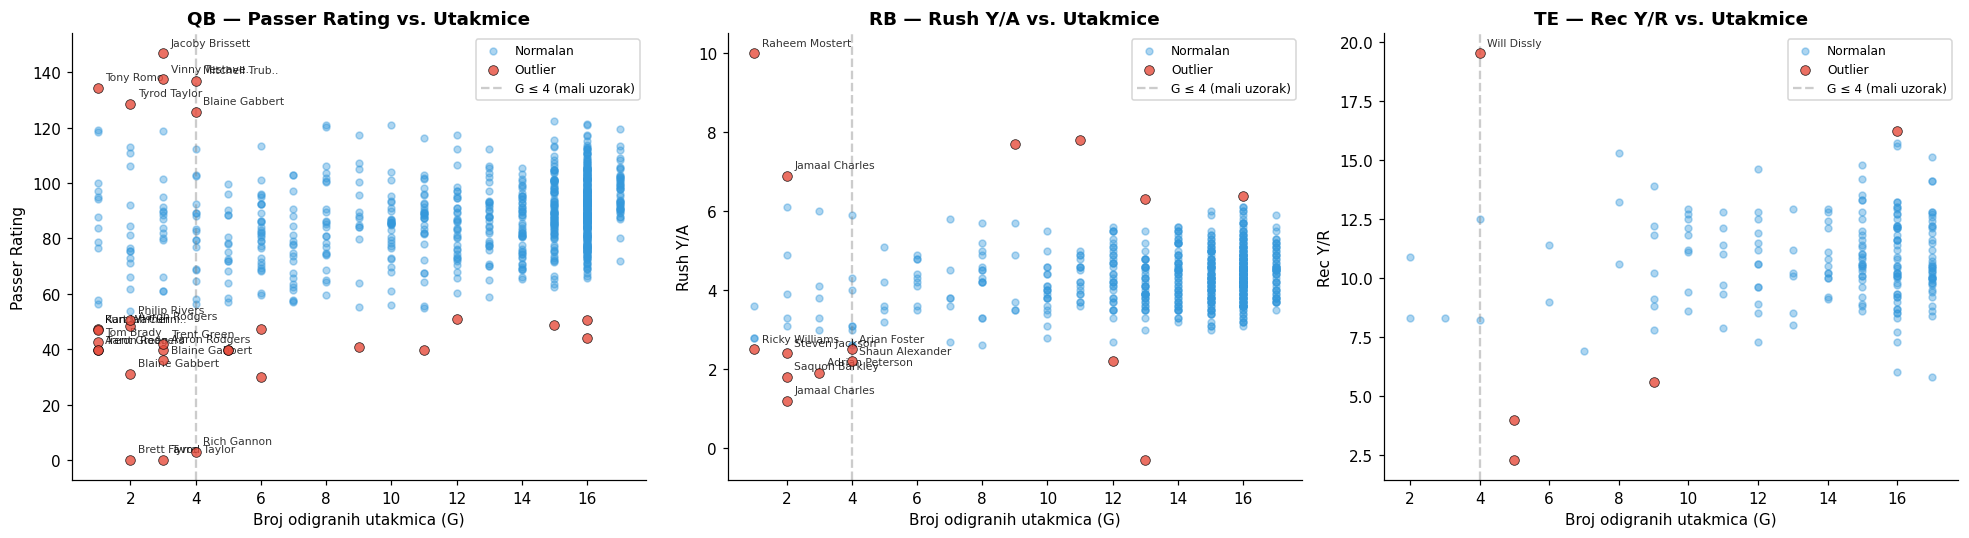


Outlieri s malim uzorkom (G ≤ 4):

  QB : 30 outliera, od toga 20 (66.7%) s G ≤ 4
  RB : 15 outliera, od toga 9 (60.0%) s G ≤ 4
  TE : 5 outliera, od toga 1 (20.0%) s G ≤ 4


In [21]:
# Scatter: G vs ključna metrika, outlieri obojeni
scatter_config = {
    "QB": {"df": qb, "x": "G", "y": "Rate", "id": "Player", "label": "Passer Rating"},
    "RB": {"df": rb, "x": "G", "y": "Rush_Y/A", "id": "Player", "label": "Rush Y/A"},
    "TE": {"df": te, "x": "G", "y": "Rec_Y/R", "id": "Player", "label": "Rec Y/R"},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pos, cfg) in zip(axes, scatter_config.items()):
    df_pos = cfg["df"].dropna(subset=[cfg["x"], cfg["y"]])
    y = df_pos[cfg["y"]]
    q1, q3 = y.quantile(0.25), y.quantile(0.75)
    iqr = q3 - q1
    is_outlier = (y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)

    # Normalne tačke
    ax.scatter(df_pos.loc[~is_outlier, cfg["x"]], df_pos.loc[~is_outlier, cfg["y"]],
               alpha=0.4, s=20, color="#3498db", label="Normalan")
    # Outlieri
    ax.scatter(df_pos.loc[is_outlier, cfg["x"]], df_pos.loc[is_outlier, cfg["y"]],
               alpha=0.8, s=40, color="#e74c3c", edgecolors="black", linewidth=0.5, label="Outlier", zorder=5)

    # Označi igrače s malo utakmica i ekstremnim vrijednostima
    small_sample = is_outlier & (df_pos[cfg["x"]] <= 4)
    for idx in df_pos[small_sample].index:
        name = df_pos.loc[idx, cfg["id"]]
        if len(name) > 15:
            name = name[:13] + ".."
        ax.annotate(name, (df_pos.loc[idx, cfg["x"]], df_pos.loc[idx, cfg["y"]]),
                    fontsize=7, alpha=0.8, xytext=(5, 5), textcoords="offset points")

    ax.axvline(4, color="gray", linestyle="--", alpha=0.4, label="G ≤ 4 (mali uzorak)")
    ax.set_xlabel("Broj odigranih utakmica (G)")
    ax.set_ylabel(cfg["label"])
    ax.set_title(f"{pos} — {cfg['label']} vs. Utakmice", fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Statistika: koliko outliera ima G <= 4
print("\nOutlieri s malim uzorkom (G ≤ 4):\n")
for pos, cfg in scatter_config.items():
    df_pos = cfg["df"].dropna(subset=[cfg["x"], cfg["y"]])
    y = df_pos[cfg["y"]]
    q1, q3 = y.quantile(0.25), y.quantile(0.75)
    iqr = q3 - q1
    is_outlier = (y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)
    n_out = is_outlier.sum()
    n_small = (is_outlier & (df_pos[cfg["x"]] <= 4)).sum()
    print(f"  {pos:3s}: {n_out} outliera, od toga {n_small} ({round(n_small/max(n_out,1)*100,1)}%) s G ≤ 4")


**Nalazi — Mali Uzorak vs. Elitne Performanse:**

- **QB**: Čak **66.7% outliera** u Passer Ratingu dolazi od igrača s ≤4 odigrane utakmice. Ovo su najčešće backup QB-ovi koji su ušli u igru na kratko i imali ili izuzetno dobru ili katastrofalnu predstavu (npr. savršen rating od 158.3 u jednoj utakmici, ili 0.0). Ovi outlieri su **artefakti malog uzorka** i trebaju se filtrirati pri modeliranju.

- **RB**: Sličan obrazac — **60% outliera** u Rush Y/A ima ≤4 utakmice. Running backovi s malo nošenja mogu imati ekstremno visok (npr. jedan dugačak run) ili nizak prosjek.

- **TE**: Samo **20% outliera** dolazi iz malog uzorka. Tight end outlieri su većinom legitimne ekstremne sezone (npr. Will Dissly s visokim Y/R u punoj sezoni).

**Preporuka za modeliranje**: Filtrirati igrače s manje od 4-5 odigranih utakmica kako bi se eliminisali artefakti malog uzorka i zadržali samo statistički značajni outlieri koji predstavljaju stvarne elitne performanse.

### Poređenje IQR i Z-Score Metoda — Koliko Outliera Detektuje Svaka?

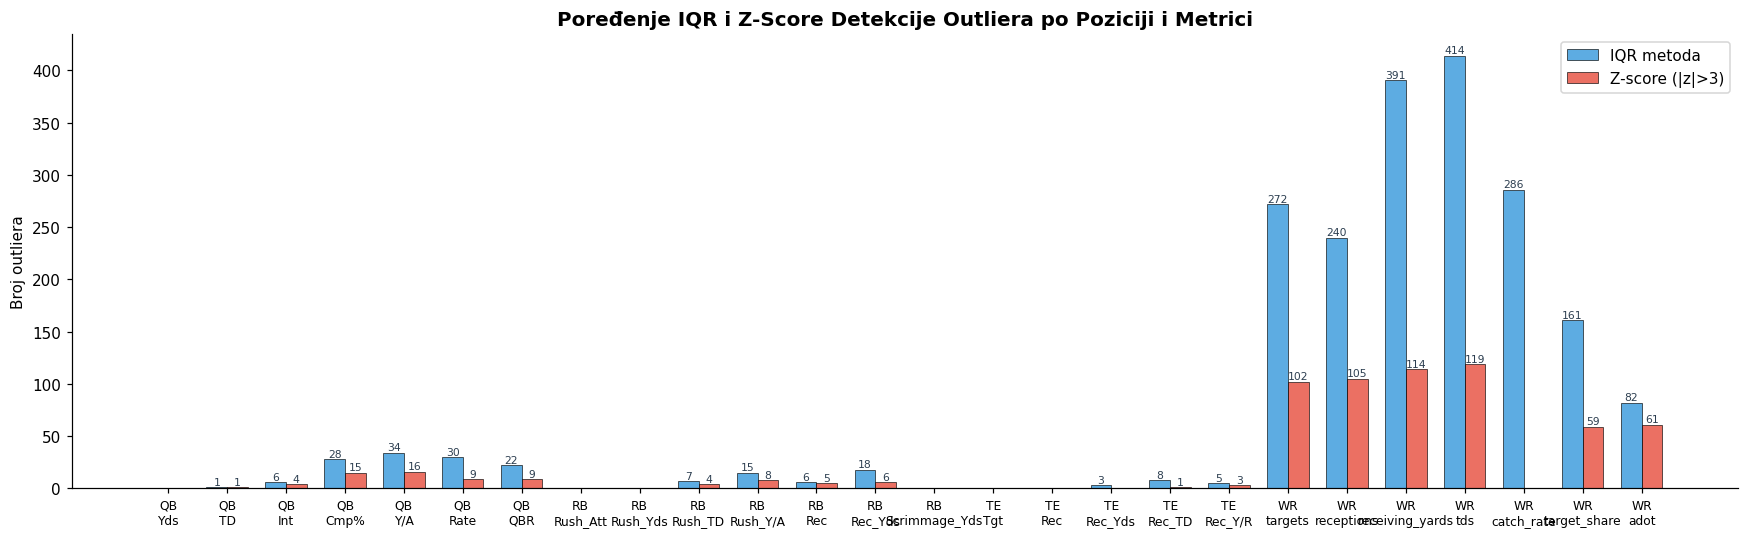


Ukupno outliera po poziciji:



,IQR outliera,Z-score outliera,Razlika (IQR - Z)
Pozicija,,,
QB,121,54,67
RB,46,23,23
TE,16,4,12
WR,1846,560,1286


In [22]:
# Poređenje: IQR vs Z-score broj outliera po poziciji
compare_rows = []
for pos, info in key_cols.items():
    df_pos = info["df"]
    for col in info["cols"]:
        s = df_pos[col].dropna()
        if s.empty:
            continue

        # IQR
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        n_iqr = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

        # Z-score
        z = np.abs(stats.zscore(s))
        n_z = (z > 3).sum()

        compare_rows.append({
            "Pozicija": pos,
            "Kolona": col,
            "IQR outliera": n_iqr,
            "Z-score outliera": n_z,
            "Samo IQR": n_iqr - n_z if n_iqr > n_z else 0,
            "Samo Z-score": n_z - n_iqr if n_z > n_iqr else 0,
        })

compare_df = pd.DataFrame(compare_rows)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(compare_df))
width = 0.35

bars1 = ax.bar(x - width/2, compare_df["IQR outliera"], width, label="IQR metoda", color="#3498db", alpha=0.8, edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, compare_df["Z-score outliera"], width, label="Z-score (|z|>3)", color="#e74c3c", alpha=0.8, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['Pozicija']}\n{r['Kolona']}" for _, r in compare_df.iterrows()], fontsize=8, rotation=0)
ax.set_ylabel("Broj outliera")
ax.set_title("Poređenje IQR i Z-Score Detekcije Outliera po Poziciji i Metrici", fontweight="bold", fontsize=13)
ax.legend()

# Dodaj brojeve iznad barova
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=7, color="#2c3e50")
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(int(bar.get_height())),
                ha="center", va="bottom", fontsize=7, color="#2c3e50")

plt.tight_layout()
plt.show()

# Ukupni sažetak
print("\nUkupno outliera po poziciji:\n")
summary = compare_df.groupby("Pozicija")[["IQR outliera", "Z-score outliera"]].sum()
summary["Razlika (IQR - Z)"] = summary["IQR outliera"] - summary["Z-score outliera"]
display(summary)

**Poređenje metoda — Ključni nalazi:**

IQR metoda konzistentno detektuje **više outliera** od Z-score metode za sve pozicije. To je očekivano jer:
- IQR koristi fiksni prag od 1.5× interkvartilnog raspona, što je **osjetljivije** na umjereno ekstremne vrijednosti
- Z-score s pragom |z|>3 detektuje samo **statistički ekstremne** tačke (>3σ) — strožiji kriterij

| Pozicija | IQR outliera | Z-score outliera | Razlika |
|----------|:---:|:---:|:---:|
| QB | 121 | 54 | +67 |
| RB | 46 | 23 | +23 |
| TE | 16 | 4 | +12 |
| WR | 1.846 | 560 | +1.286 |

- **WR skup** ima daleko najviše outliera jer sadrži 5.529 redova — mnogi igrači imaju minimalne statistike (npr. 1-2 targeta u sezoni), što stvara duge repove distribucije. IQR metoda ih sve hvata kao outliere, dok Z-score filtrira samo najekstremnije.
- **QB i RB**: IQR detektuje oko 2× više outliera nego Z-score — ovo su uglavnom igrači s malim brojem utakmica (G≤4) koji imaju per-game metrike daleko od prosjeka.
- **TE**: Najmanji skup (194 reda) s relativno malo outliera u obje metode.

**Odluka za modeliranje**: Koristimo kombinaciju oba pristupa — IQR za identifikaciju "sumnjivih" observacija i minimum utakmica (G≥4-5) kao filter za eliminaciju artefakata malog uzorka. Z-score outlieri s visokim brojem utakmica se zadržavaju jer predstavljaju legitimne elitne performanse.